In [1]:
import sys
# here, either reference to satclip repo goes, or can try and create git submodule 🤷‍♀️ 
# https://github.com/microsoft/satclip/tree/main
sys.path.append('/home/cbutsko/Desktop/cbutsko_experiments/satclip/satclip')

# general
import numpy as np
import pandas as pd
import itertools
import gc
import re
import torch
import glob
import rioxarray
import xarray as xr
import rasterio as rio
from rasterio import plot as rio_plot
import os

# modeling
from catboost import CatBoostClassifier, Pool
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, precision_score, recall_score
from sklearn.model_selection import train_test_split
# from sklearn.utils.validation import check_is_fitted, check_array
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# plotting and output
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from cbutsko_utils import plot_confusion_matrix
import warnings
warnings.filterwarnings(action='ignore')
tqdm.pandas()

# SatClip libs
from load import get_satclip
from cbutsko_utils import prepare_satclip_embeddings

# processing utils
from cbutsko_utils import patch2feats, process_raw_features_input_df

# hierarchical clsfc libs
from hiclass import LocalClassifierPerParentNode, LocalClassifierPerNode
from cbutsko_utils import CatBoostClassifierWrapper, LocalClassifierPerNodeWrapper, LocalClassifierPerParentNodeWrapper

In [2]:
# read files with mappings to crop names and hierarchy

label_columns = ['cropland', 'landcover', 'cropgroup', 'croptype']

wc2ec_map = pd.read_csv('resources/wc2eurocrops_map.csv')
ec_map = pd.read_csv('resources/eurocrops_map_wcr_edition.csv', index_col='ec_code')

In [3]:
# read parquet files, assign hierarchical labels and do small clean-ups 
tpath = '/vitodata/worldcereal/features/benchmarking_features/calval/'
freq = 'monthly'

data_df = process_raw_features_input_df(
    '{}rawts-{}_calval.parquet'.format(tpath, freq),
    wc2ec_map,
    ec_map,
    label_columns,
    add_countries=True
    )

In [ ]:
# data_df = data_df[['cropland_wc']+['ref_id','lat','lon','CROPTYPE_NAME','country_code']]
# gc.collect()

In [4]:
data_df.shape

(839023, 214)

In [ ]:
# add pre-computed presto features 
# presto_df = pd.read_parquet('{}pretrainedprestofts-{}_calval.parquet'.format(tpath,freq))
presto_df = pd.read_parquet('{}prestofts-{}_calval.parquet'.format(tpath,freq))

presto_df.set_index('sample_id', inplace=True)
presto_emb_feats = [xx for xx in presto_df.columns if 'presto_ft' in xx]

data_df = pd.concat([data_df,presto_df[presto_emb_feats]], join='inner', axis=1)
del presto_df
gc.collect()

### SatCLIP embeddings

1. Get the embeddings themselves for train samples

In [5]:
# again, here goes either path to a model, or git submodule can be created 🤷‍♀️
n_rows = data_df.shape[0]
n_pcs = 32
# models = ['resnet18-l10','resnet18-l40','vit16-l40']
models = ['resnet18-l10','vit16-l40']

for model_name in models:
    model_path = '/home/cbutsko/Desktop/cbutsko_experiments/satclip-{}.ckpt'.format(model_name)
    satclip_model = get_satclip(model_path, device='cpu')
    satclip_df = prepare_satclip_embeddings(satclip_model, model_name, data_df)
    # satclip_emb_feats = [xx for xx in satclip_df.columns if 'satclip_{}_ft'.format(model_name) in xx]
    del satclip_model
    gc.collect()

    satclip_pca_feats = ['satclip_{}_PC{}'.format(model_name,jj) for jj in range(n_pcs)]
    satclip_pca_model = PCA(n_components=n_pcs)
    scaler = StandardScaler()
    scaler.fit(satclip_df.sample(n=int(0.7*n_rows)).values)
    satclip_emb_norm = scaler.transform(satclip_df.values)
    satclip_pca_model.fit(satclip_emb_norm[np.random.randint(n_rows, size=int(0.7*n_rows)),:])
    gc.collect()
    satclip_pca = satclip_pca_model.transform(satclip_emb_norm)
    satclip_pca_df = pd.DataFrame(
        satclip_pca, 
        columns=satclip_pca_feats, 
        index=data_df.index)
    
    data_df = pd.concat([data_df,satclip_pca_df], join='inner', axis=1)
    del satclip_pca_df
    gc.collect()

    # if model_name=='resnet18-l10':
    #     data_df = pd.concat([data_df,satclip_df], join='inner', axis=1)
    del satclip_df
    gc.collect()

using pretrained moco resnet18


  0%|          | 0/84 [00:00<?, ?it/s]

using pretrained moco vit16


  0%|          | 0/84 [00:00<?, ?it/s]

In [6]:
data_df.shape

(839023, 278)

2. Fit PCA on (part of) data, transform SatCLIP embeddings into PCs and append them to main dataframes

In [ ]:
# n_rows = data_df.shape[0]
# n_pcs = 32
# satclip_pca_feats = ['satclip_resnet18_l10_PC{}'.format(jj) for jj in range(n_pcs)]
# satclip_emb_resnet18_l10_feats = [xx for xx in data_df.columns if 'satclip_resnet18-l10_ft' in xx]

# satclip_pca_model = PCA(n_components=n_pcs)
# scaler = StandardScaler()
# scaler.fit(data_df[satclip_emb_resnet18_l10_feats].sample(n=int(0.7*n_rows)).values)
# satclip_emb_norm = scaler.transform(data_df[satclip_emb_resnet18_l10_feats].values)
# satclip_pca_model.fit(satclip_emb_norm[np.random.randint(n_rows, size=int(0.7*n_rows)),:])
# gc.collect()
# satclip_pca = satclip_pca_model.transform(satclip_emb_norm)
# satclip_pca_df = pd.DataFrame(
#     satclip_pca, 
#     columns=satclip_pca_feats, 
#     index=data_df.index)

# data_df = pd.concat([data_df,satclip_pca_df], join='inner', axis=1)

# del satclip_pca_df
# gc.collect()

### Classification

In [15]:
# group feature names for easier use
n_ts = 12

optical12_feats = [xx for xx in data_df.columns if re.search(r'OPTICAL.*ts({})-'.format('|'.join(map(str, list(range(n_ts))))), xx)]
sar12_feats = [xx for xx in data_df.columns if re.search(r'SAR.*ts({})-'.format('|'.join(map(str, list(range(n_ts))))), xx)]
temp12_feats  = [xx for xx in data_df.columns if re.search(r'METEO-temp.*ts({})-'.format('|'.join(map(str, list(range(n_ts))))), xx)]
prcp12_feats  = [xx for xx in data_df.columns if re.search(r'METEO-precip.*ts({})-'.format('|'.join(map(str, list(range(n_ts))))), xx)]
dem_feats = ['DEM-alt-20m', 'DEM-slo-20m']
latlon_feats = ['lat','lon']
biome_feats = [xx for xx in data_df.columns if 'biome' in xx]

# satclip_emb_feats = [xx for xx in data_df.columns if 'satclip_ft' in xx]
satclip_emb_resnet18_l10_feats = [xx for xx in data_df.columns if 'satclip_resnet18-l10_ft' in xx]

presto_emb_feats = [xx for xx in data_df.columns if 'presto_ft' in xx]

satclip_pca_resnet18_l10_feats = [xx for xx in data_df.columns if 'satclip_resnet18-l10_PC' in xx]
satclip_pca_resnet18_l40_feats = [xx for xx in data_df.columns if 'satclip_resnet18-l40_PC' in xx]
satclip_pca_vit16_l40_feats = [xx for xx in data_df.columns if 'satclip_vit16-l40_PC' in xx]

NameError: name 'data_df' is not defined

In [ ]:
# for ts in range(n_ts):
#     B04 = data_df['OPTICAL-B04-ts{}-10m'.format(ts)]
#     B08 = data_df['OPTICAL-B08-ts{}-10m'.format(ts)]
#     _ndvi = (B08 - B04) / (B08 + B04)
#     data_df['NDVI-ts{}-10m'.format(ts)] = _ndvi
#     del B04,B08,_ndvi
#     gc.collect()

# ndvi_feats = [xx for xx in data_df.columns if re.search(r'NDVI.*ts({})-'.format('|'.join(map(str, list(range(n_ts))))), xx)]

In [8]:
# minor ammendments for smooth processing
# delete 5 points that for some reason don't have country
data_df = data_df[data_df['country_code'].notna()]
# delete 1 point that belongs to the country with only 1 point
data_df = data_df[data_df['country_code']!='DMA']
gc.collect()

0

In [ ]:
data_df = data_df[data_df['cropland_wc']==1]

In [ ]:
crop = 'Maize'

In [ ]:
data_df['CROPTYPE_NAME'].value_counts().iloc[:20]

In [ ]:
data_df[data_df['country_code']=='NGA']['CROPTYPE_NAME'].value_counts().iloc[:20]

In [ ]:
data_df['is_crop'] = data_df['CROPTYPE_NAME']==crop

In [9]:
# Define features to use, label, year and/or AEZ to leave out
label_col = 'cropland_wc'
# label_col = 'is_crop'
# features_list = presto_emb_feats
features_list = optical12_feats + sar12_feats + satclip_emb_resnet18_l10_feats
# features_list = optical12_feats + sar12_feats + temp12_feats + prcp12_feats + dem_feats + latlon_feats

In [ ]:
sample_size = 50
counties_lst = data_df[data_df['CROPTYPE_NAME']==crop]['country_code'].value_counts()
counties_lst = counties_lst[counties_lst>=20].index

In [ ]:
counties_lst

In [ ]:
def _get_metrics(df, country):
    _f1 = df[df['country_code']==country]['f1'].values[0]
    _precision = df[df['country_code']==country]['precision'].values[0]
    _recall = df[df['country_code']==country]['recall'].values[0]
    return _f1, _precision, _recall

In [ ]:
for country in counties_lst: 

    _ndvi_subset = data_df[
        (data_df['country_code']==country) &
        (data_df['CROPTYPE_NAME']==crop)
        ]
        
    n_points = len(_ndvi_subset)
    if n_points>sample_size:
        ndvis = _ndvi_subset.sample(n=sample_size)[ndvi_feats].transpose()
    else:
        ndvis = _ndvi_subset[ndvi_feats].transpose()
    
    ndvis[(ndvis.abs()>1) | (ndvis==0)] = np.nan
    # ndvis.fillna(method='ffill', axis=0, inplace=True)
    
    f1_raw_ts_loo, precision_raw_ts_loo, recall_raw_ts_loo = _get_metrics(country_loo_res_raw_ts, country)
    f1_raw_ts_random, precision_raw_ts_random, recall_raw_ts_random = _get_metrics(random_split_res_raw_ts, country)
    f1_presto_loo, precision_presto_loo, recall_presto_loo = _get_metrics(country_loo_res_fnt_presto, country)
    f1_presto_random, precision_presto_random, recall_presto_random = _get_metrics(random_split_res_fnt_presto, country)

    if n_points>sample_size:
        n_obs = sample_size
    else:
        n_obs = n_points

    ndvis.plot(figsize=(15,9), legend=None)
    plt.title(f"""
    {crop}, {country} (random {n_obs} samples)
    Raw TS model (LOO) metrics:
    F1: {f1_raw_ts_random:.2f} ({f1_raw_ts_loo:.2f}); Precision: {precision_raw_ts_random:.2f} ({precision_raw_ts_loo:.2f}); Recall: {recall_raw_ts_random:.2f} ({recall_raw_ts_loo:.2f})
    Finetuned Presto model (LOO) metrics:
    F1: {f1_presto_random:.2f} ({f1_presto_loo:.2f}); Precision: {precision_presto_random:.2f} ({precision_presto_loo:.2f}); Recall: {recall_presto_random:.2f} ({recall_presto_loo:.2f})
    """)
    plt.savefig('/home/cbutsko/Desktop/cbutsko_experiments/crop_charts/{}_{}.png'.format(crop,country), dpi=300)

In [ ]:
test_country = 'USA'

X_trnval_df = data_df[data_df['country_code']!=test_country][features_list]
y_trnval_df = data_df[data_df['country_code']!=test_country][label_col]
X_tst_df = data_df[data_df['country_code']==test_country][features_list]
y_tst_df = data_df[data_df['country_code']==test_country][label_col]

# initialize and train the model
model = CatBoostClassifier(
    iterations=500, 
    depth=8,
    eval_metric='F1',
    learning_rate=0.3,
    l2_leaf_reg=100,
    verbose=50,
    random_seed=42,
    )

model.fit(X_trnval_df, y_trnval_df)
probs = model.predict_proba(X_tst_df)
pred = model.predict(X_tst_df).flatten()
if y_tst_df.nunique()==2:
    pred = np.array([xx=='True' for xx in pred])

# create dataframe with predictions and useful attributes
preds_df = pd.DataFrame([y_tst_df.values, pred]).transpose()
preds_df.columns = ['true','pred']
preds_df['crop_prob'] = probs[:,1]
preds_df.set_index(data_df[data_df['country_code']==test_country].index, inplace=True)
attr_lst = ['ref_id','lat','lon','CROPTYPE_NAME','country_code']
preds_df[attr_lst] = data_df[data_df['country_code']==test_country][attr_lst]
preds_df.to_csv('/home/cbutsko/Desktop/cbutsko_experiments/{}_predictions.csv'.format(test_country))

In [ ]:
preds_df.groupby(['ref_id','CROPTYPE_NAME'])['pred'].value_counts().sort_index().iloc[:20]

In [ ]:
preds_df.groupby(['ref_id']).apply(lambda xx: pd.Series({
    'n_pixels': xx['ref_id'].count(),
    'n_cropland_pixels': xx['true'].sum(),
    'f1': f1_score(xx['true'], xx['pred']),
    'accuracy': (xx['true']==xx['pred']).sum()/xx['true'].count()
    }))

In [ ]:
invalid_obs = data_df[features_list].isna().sum(axis=1)>0
invalid_obs = list(invalid_obs[invalid_obs==1].index)

data_df = data_df[~data_df.index.isin(invalid_obs)] 
# data_df.drop(invalid_obs, axis=1, inplace=True)
gc.collect()

In [ ]:
res_fpath = '/home/cbutsko/Desktop/cbutsko_experiments/country_loo_res_optical_sar_satclip_pca_resnet18_l10.csv'
# res_fpath = '/home/cbutsko/Desktop/cbutsko_experiments/country_loo_res_all_raw_features_no_emb.csv'
min_points_per_country = 1000

countries_lst = data_df['country_code'].value_counts()
countries_lst = countries_lst[countries_lst>min_points_per_country].index
# countries_lst = data_df[data_df['CROPTYPE_NAME']==crop]['country_code'].value_counts().index[:40]

if os.path.isfile(res_fpath):
    country_loo_res = pd.read_csv(res_fpath)
    if 'Unnamed: 0' in country_loo_res.columns:
        country_loo_res.drop('Unnamed: 0', axis=1, inplace=True)
    computed_countries = country_loo_res['country_code'].nunique()
    countries_lst = countries_lst[computed_countries:]
else: 
    country_loo_res = pd.DataFrame()


# n_pcs = 32
# presto_pca_feats = ['presto_PC{}'.format(jj) for jj in range(n_pcs)]


pbar = tqdm(total=len(countries_lst))
for test_country in countries_lst:
    pbar.update(1)

    X_trnval_df = data_df[data_df['country_code']!=test_country][features_list]
    y_trnval_df = data_df[data_df['country_code']!=test_country][label_col]
    X_tst_df = data_df[data_df['country_code']==test_country][features_list]
    y_tst_df = data_df[data_df['country_code']==test_country][label_col]

    # n_rows = X_trnval_df.shape[0]
    # presto_pca_model = PCA(n_components=n_pcs)
    # scaler = StandardScaler()
    # scaler.fit(X_trnval_df.sample(n=int(0.7*n_rows)).values)
    # presto_emb_norm_trn = scaler.transform(X_trnval_df.values)
    # presto_emb_norm_tst = scaler.transform(X_tst_df.values)
    # presto_pca_model.fit(presto_emb_norm_trn[np.random.randint(n_rows, size=int(0.7*n_rows)),:])
    # gc.collect()
    # presto_pca_trn = presto_pca_model.transform(presto_emb_norm_trn)
    # presto_pca_tst = presto_pca_model.transform(presto_emb_norm_tst)

    # initialize and train the model
    model = CatBoostClassifier(
        iterations=500, 
        depth=8,
        eval_metric='F1',
        learning_rate=0.3,
        l2_leaf_reg=100,
        verbose=0,
        random_seed=42,
        )

    # model.fit(presto_pca_trn, y_trnval_df)
    # probs = model.predict_proba(presto_pca_tst)
    # pred = model.predict(presto_pca_tst).flatten()

    model.fit(X_trnval_df, y_trnval_df)
    probs = model.predict_proba(X_tst_df)
    pred = model.predict(X_tst_df).flatten()

    if y_tst_df.nunique()==2:
        pred = np.array([xx=='True' for xx in pred])

    # create dataframe with predictions and useful attributes
    preds_df = pd.DataFrame([y_tst_df.values, pred]).transpose()
    preds_df.columns = ['true','pred']
    preds_df['crop_prob'] = probs[:,1]
    preds_df.set_index(data_df[data_df['country_code']==test_country].index, inplace=True)
    attr_lst = ['ref_id','lat','lon','CROPTYPE_NAME','country_code']
    preds_df[attr_lst] = data_df[data_df['country_code']==test_country][attr_lst]
    tres = preds_df.groupby(['ref_id','country_code']).apply(lambda xx: pd.Series({
        'f1': f1_score(xx['true'], xx['pred'])
        })).reset_index()
    # tres = tres[tres['country_code']==test_country]

    country_loo_res = pd.concat((country_loo_res,tres), axis=0)
    country_loo_res.to_csv(res_fpath)

    gc.collect()

In [ ]:
# country_loo_res_raw_ts = country_loo_res.copy()
country_loo_res_fnt_presto = country_loo_res.copy()

**Compute metrics on country-stratified random split**

In [ ]:
data_df = data_df.sample(frac=1)
# .reset_index(drop=True)
n_splits = 4
split_inds = np.array_split(range(len(data_df)), n_splits)

# trn_df, val_df = train_test_split(
#     data_df,
#     stratify=data_df['country_code'],
#     test_size=0.3,
#     random_state=42)
# X_trnval_df = trn_df[features_list]
# y_trnval_df = trn_df[label_col]
# X_tst_df = val_df[features_list]
# y_tst_df = val_df[label_col]

preds_df = pd.DataFrame()
for tsplit in range(n_splits):
    trn_inds = [x for xs in [xx for ii,xx in enumerate(split_inds) if ii!=tsplit]  for x in xs]
    val_inds = split_inds[tsplit]

    X_trnval_df = data_df.iloc[trn_inds][features_list]
    y_trnval_df = data_df.iloc[trn_inds][label_col]
    X_tst_df = data_df.iloc[val_inds][features_list]
    y_tst_df = data_df.iloc[val_inds][label_col]

    # initialize and train the model
    model = CatBoostClassifier(
        iterations=500, 
        depth=8,
        eval_metric='F1',
        learning_rate=0.3,
        l2_leaf_reg=100,
        verbose=100,
        random_seed=42,
        )

    model.fit(X_trnval_df, y_trnval_df)
    probs = model.predict_proba(X_tst_df)
    pred = model.predict(X_tst_df).flatten()
    if y_tst_df.nunique()==2:
        pred = np.array([xx=='True' for xx in pred])

    # create dataframe with predictions and useful attributes
    _preds_df = pd.DataFrame([y_tst_df.values, pred]).transpose()
    _preds_df.columns = ['true','pred']
    _preds_df['crop_prob'] = probs[:,1]
    _preds_df.set_index(data_df.iloc[val_inds].index, inplace=True)
    attr_lst = ['ref_id','lat','lon','CROPTYPE_NAME','country_code']
    _preds_df[attr_lst] = data_df.iloc[val_inds][attr_lst]
    preds_df = pd.concat((preds_df,_preds_df), axis=0)

    gc.collect()

preds_df.to_csv('/home/cbutsko/Desktop/cbutsko_experiments/country_stratified_split_finetuned_presto.csv')

In [ ]:
data_df.iloc[val_inds]

In [ ]:
tres = preds_df.groupby(['ref_id','country_code','CROPTYPE_NAME']).apply(lambda xx: pd.Series({
    'n_pixels': xx['pred'].count(),
    'predicted_as_crop': xx['pred'].sum(),
    'confidently_predicted_as_crop': xx[xx['crop_prob']>0.7]['pred'].sum(),
    'predicted_as_not_crop': (~xx['pred']).sum(),
    'confidently_predicted_as_not_crop': (xx['crop_prob']<0.3).sum(),
})).reset_index()
tres.to_csv('/home/cbutsko/Desktop/cbutsko_experiments/finetuned_presto_binary_stats_by_croptype.csv')

In [ ]:
tres

In [ ]:
# random_split_res_raw_ts = tres.copy()
random_split_res_fnt_presto = tres.copy()

In [ ]:
# presto_emb_feats
print(classification_report(
    preds_df['true'], 
    preds_df['pred'], 
    target_names=['not_maize','maize'])) 

In [ ]:
# optical12_feats + sar12_feats + temp12_feats + prcp12_feats + dem_feats + latlon_feats
print(classification_report(
    preds_df['true'], 
    preds_df['pred'], 
    target_names=['not_maize','maize'])) 

In [ ]:
tres = preds_df.groupby(['country_code']).apply(lambda xx: pd.Series({
    'n_pixels': xx['ref_id'].count(),
    'n_maize_pixels': xx[xx['CROPTYPE_NAME']=='Maize']['ref_id'].count(),
    'f1': f1_score(xx['true'], xx['pred']),
    'precision': precision_score(xx['true'], xx['pred']),
    'recall': recall_score(xx['true'], xx['pred']),
    })).reset_index()

In [ ]:
# presto_emb_feats
tres.sort_values(by='n_maize_pixels', ascending=False).iloc[:20]

In [ ]:
tres

In [ ]:
# optical12_feats + sar12_feats + temp12_feats + prcp12_feats + dem_feats + latlon_feats
tres.sort_values(by='n_maize_pixels', ascending=False).iloc[:20]

In [10]:
trn_df, val_df = train_test_split(
    data_df,
    stratify=data_df['country_code'],
    test_size=0.3,
    random_state=42)

del data_df
gc.collect()

0

In [11]:
features_list = optical12_feats + sar12_feats

X_trnval_df = trn_df[features_list]
y_trnval_df = trn_df[label_col]
X_tst_df = val_df[features_list]
y_tst_df = val_df[label_col]
optical_sar_model = CatBoostClassifier(
    iterations=500, 
    depth=8,
    eval_metric='F1',
    learning_rate=0.3,
    l2_leaf_reg=100,
    verbose=50,
    random_seed=42,
    )
optical_sar_model.fit(X_trnval_df, y_trnval_df)
gc.collect()

0:	learn: 0.5910279	total: 378ms	remaining: 3m 8s
50:	learn: 0.7918697	total: 10.5s	remaining: 1m 32s
100:	learn: 0.8138242	total: 23.7s	remaining: 1m 33s
150:	learn: 0.8261542	total: 35.6s	remaining: 1m 22s
200:	learn: 0.8352264	total: 47.3s	remaining: 1m 10s
250:	learn: 0.8423013	total: 58.5s	remaining: 58s
300:	learn: 0.8492170	total: 1m 11s	remaining: 47s
350:	learn: 0.8547718	total: 1m 23s	remaining: 35.6s
400:	learn: 0.8598884	total: 1m 36s	remaining: 23.8s
450:	learn: 0.8649717	total: 1m 49s	remaining: 11.9s
499:	learn: 0.8691868	total: 2m 1s	remaining: 0us


0

In [12]:
features_list = optical12_feats + sar12_feats + satclip_emb_resnet18_l10_feats

X_trnval_df = trn_df[features_list]
y_trnval_df = trn_df[label_col]
X_tst_df = val_df[features_list]
y_tst_df = val_df[label_col]
optical_sar_satclip_emb_model = CatBoostClassifier(
    iterations=500, 
    depth=8,
    eval_metric='F1',
    learning_rate=0.3,
    l2_leaf_reg=100,
    verbose=50,
    random_seed=42,
    )
optical_sar_satclip_emb_model.fit(X_trnval_df, y_trnval_df)
gc.collect()

0:	learn: 0.5853035	total: 977ms	remaining: 8m 7s
50:	learn: 0.8026020	total: 22.8s	remaining: 3m 20s
100:	learn: 0.8262841	total: 43.5s	remaining: 2m 51s
150:	learn: 0.8399446	total: 1m 4s	remaining: 2m 27s
200:	learn: 0.8487277	total: 1m 24s	remaining: 2m 6s
250:	learn: 0.8559141	total: 1m 46s	remaining: 1m 45s
300:	learn: 0.8617816	total: 2m 7s	remaining: 1m 24s
350:	learn: 0.8665761	total: 2m 28s	remaining: 1m 3s
400:	learn: 0.8710739	total: 2m 49s	remaining: 41.8s
450:	learn: 0.8754097	total: 3m 9s	remaining: 20.6s
499:	learn: 0.8794221	total: 3m 30s	remaining: 0us


0

In [12]:
features_list = optical12_feats + sar12_feats + temp12_feats + prcp12_feats + dem_feats + latlon_feats

X_trnval_df = trn_df[features_list]
y_trnval_df = trn_df[label_col]
X_tst_df = val_df[features_list]
y_tst_df = val_df[label_col]
optical_sar_plus_model = CatBoostClassifier(
    iterations=500, 
    depth=8,
    eval_metric='F1',
    learning_rate=0.3,
    l2_leaf_reg=100,
    verbose=50,
    random_seed=42,
    )
optical_sar_plus_model.fit(X_trnval_df, y_trnval_df)
gc.collect()

0:	learn: 0.5830999	total: 336ms	remaining: 2m 47s
50:	learn: 0.8046935	total: 13.2s	remaining: 1m 56s
100:	learn: 0.8297734	total: 26.5s	remaining: 1m 44s
150:	learn: 0.8424987	total: 38.2s	remaining: 1m 28s
200:	learn: 0.8521304	total: 49.6s	remaining: 1m 13s
250:	learn: 0.8594065	total: 1m	remaining: 1m
300:	learn: 0.8652501	total: 1m 11s	remaining: 47.5s
350:	learn: 0.8707324	total: 1m 23s	remaining: 35.3s
400:	learn: 0.8760134	total: 1m 34s	remaining: 23.4s
450:	learn: 0.8805392	total: 1m 45s	remaining: 11.5s
499:	learn: 0.8850841	total: 1m 56s	remaining: 0us


0

In [13]:
features_list = optical12_feats + sar12_feats + satclip_pca_resnet18_l10_feats

X_trnval_df = trn_df[features_list]
y_trnval_df = trn_df[label_col]
X_tst_df = val_df[features_list]
y_tst_df = val_df[label_col]
optical_sar_satclip_resnet18_l10_pca_model = CatBoostClassifier(
    iterations=500, 
    depth=8,
    eval_metric='F1',
    learning_rate=0.3,
    l2_leaf_reg=100,
    verbose=50,
    random_seed=42,
    )
optical_sar_satclip_resnet18_l10_pca_model.fit(X_trnval_df, y_trnval_df)
gc.collect()

0:	learn: 0.5935571	total: 314ms	remaining: 2m 36s
50:	learn: 0.8047752	total: 11.2s	remaining: 1m 38s
100:	learn: 0.8273161	total: 22.7s	remaining: 1m 29s
150:	learn: 0.8400971	total: 34s	remaining: 1m 18s
200:	learn: 0.8490578	total: 45.1s	remaining: 1m 7s
250:	learn: 0.8552966	total: 56.4s	remaining: 55.9s
300:	learn: 0.8613998	total: 1m 7s	remaining: 44.7s
350:	learn: 0.8669570	total: 1m 19s	remaining: 33.8s
400:	learn: 0.8720999	total: 1m 30s	remaining: 22.3s
450:	learn: 0.8768403	total: 1m 41s	remaining: 11s
499:	learn: 0.8810571	total: 1m 52s	remaining: 0us


0

In [18]:
features_list = optical12_feats + sar12_feats + satclip_pca_vit16_l40_feats

X_trnval_df = trn_df[features_list]
y_trnval_df = trn_df[label_col]
X_tst_df = val_df[features_list]
y_tst_df = val_df[label_col]
optical_sar_satclip_vit16_l40_pca_model = CatBoostClassifier(
    iterations=500, 
    depth=8,
    eval_metric='F1',
    learning_rate=0.3,
    l2_leaf_reg=100,
    verbose=50,
    random_seed=42,
    )
optical_sar_satclip_vit16_l40_pca_model.fit(X_trnval_df, y_trnval_df)
gc.collect()

0:	learn: 0.5790737	total: 685ms	remaining: 5m 42s
50:	learn: 0.8002449	total: 11.8s	remaining: 1m 44s
100:	learn: 0.8238532	total: 23.1s	remaining: 1m 31s
150:	learn: 0.8371643	total: 34.5s	remaining: 1m 19s
200:	learn: 0.8465450	total: 45.7s	remaining: 1m 8s
250:	learn: 0.8542665	total: 56.8s	remaining: 56.3s
300:	learn: 0.8605765	total: 1m 7s	remaining: 44.8s
350:	learn: 0.8659051	total: 1m 19s	remaining: 33.7s
400:	learn: 0.8707867	total: 1m 30s	remaining: 22.4s
450:	learn: 0.8758178	total: 1m 42s	remaining: 11.1s
499:	learn: 0.8802064	total: 1m 53s	remaining: 0us


169

### Spatial test

In [20]:
# path to test patches
test_patches_path = '/home/cbutsko/Desktop/cbutsko_experiments/test_patches/'
presto_fts_path = '/vitodata/worldcereal/data/openeo/inputs_presto/preprocessed_out/presto_embeddings/finetuned/'
test_patches_files = glob.glob('{}*.nc'.format(test_patches_path))
presto_fts_test_patches_files = glob.glob('{}*.nc'.format(presto_fts_path))

In [83]:
patch_ind = 11

test_patch_fpath = test_patches_files[patch_ind]
test_patch = rioxarray.open_rasterio(
    test_patch_fpath, 
    decode_times=False)
test_patch = test_patch.rio.reproject('EPSG:4326', nodata=0)

# presto_fts_test_patch_fpath = [xx for xx in presto_fts_test_patches_files if test_patch_fpath.split('/')[-1].split('_')[0] in xx][0]
# presto_fts_test_patch = rioxarray.open_rasterio(
#     presto_fts_test_patch_fpath,
#     decode_times=False)

ts_ind = 6

test_patch_rgb_ts6 = np.dstack((
    (test_patch.B04.values[ts_ind,:,:]-test_patch.B04.values[ts_ind,:,:].min()) / (test_patch.B04.values[ts_ind,:,:].max()-test_patch.B04.values[ts_ind,:,:].min()),
    (test_patch.B03.values[ts_ind,:,:]-test_patch.B03.values[ts_ind,:,:].min()) / (test_patch.B03.values[ts_ind,:,:].max()-test_patch.B03.values[ts_ind,:,:].min()),
    (test_patch.B02.values[ts_ind,:,:]-test_patch.B02.values[ts_ind,:,:].min()) / (test_patch.B02.values[ts_ind,:,:].max()-test_patch.B02.values[ts_ind,:,:].min())
    ))
test_patch_ndvi_ts6 = (test_patch.B08.values[ts_ind,:,:] - test_patch.B04.values[ts_ind,:,:]) / (test_patch.B08.values[ts_ind,:,:] + test_patch.B04.values[ts_ind,:,:])

test_patch_rgb_ts4 = np.dstack((
    (test_patch.B04.values[4,:,:]-test_patch.B04.values[4,:,:].min()) / (test_patch.B04.values[4,:,:].max()-test_patch.B04.values[4,:,:].min()),
    (test_patch.B03.values[4,:,:]-test_patch.B03.values[4,:,:].min()) / (test_patch.B03.values[4,:,:].max()-test_patch.B03.values[4,:,:].min()),
    (test_patch.B02.values[4,:,:]-test_patch.B02.values[4,:,:].min()) / (test_patch.B02.values[4,:,:].max()-test_patch.B02.values[4,:,:].min())
    ))

test_patch_name = ' '.join(test_patch_fpath.split('/')[-1].split('_')[:2])

In [84]:
test_patch_df_feats = patch2feats(test_patch, optical12_feats + sar12_feats)
test_patch_probs1 = optical_sar_model.predict_proba(test_patch_df_feats)[:,1]
test_patch_preds1 = test_patch_probs1>0.5

test_patch_df_feats = patch2feats(test_patch, optical12_feats + sar12_feats + temp12_feats + prcp12_feats + dem_feats + latlon_feats)
test_patch_probs2 = optical_sar_plus_model.predict_proba(test_patch_df_feats)[:,1]
test_patch_preds2 = test_patch_probs2>0.5

In [85]:
model_name = 'resnet18-l10'
model_path = '/home/cbutsko/Desktop/cbutsko_experiments/satclip-{}.ckpt'.format(model_name)
satclip_model = get_satclip(model_path, device='cpu')
# test_patch_df_feats = patch2feats(
#     test_patch, 
#     optical12_feats + sar12_feats + satclip_emb_resnet18_l10_feats,
#     True,
#     'emb',
#     satclip_model,
#     model_name,
#     satclip_pca_model,
#     scaler
#     )
# test_patch_probs3 = optical_sar_satclip_emb_model.predict_proba(test_patch_df_feats)[:,1]
# test_patch_preds3 = test_patch_probs3>0.5

test_patch_df_feats = patch2feats(
    test_patch, 
    optical12_feats + sar12_feats + satclip_pca_resnet18_l10_feats,
    True,
    'pca',
    satclip_model,
    model_name,
    satclip_pca_model,
    scaler
    )
test_patch_probs4 = optical_sar_satclip_resnet18_l10_pca_model.predict_proba(test_patch_df_feats)[:,1]
test_patch_preds4 = test_patch_probs4>0.5

del satclip_model
gc.collect()

# test_patch_df_feats = presto_fts_test_patch.values.reshape(128,-1).swapaxes(0,1)
# test_patch_df_feats = pd.DataFrame(test_patch_df_feats, columns=presto_emb_feats)

using pretrained moco resnet18


  0%|          | 0/2 [00:00<?, ?it/s]

18

In [86]:
model_name = 'vit16-l40'
model_path = '/home/cbutsko/Desktop/cbutsko_experiments/satclip-{}.ckpt'.format(model_name)
satclip_model = get_satclip(model_path, device='cpu')

test_patch_df_feats = patch2feats(
    test_patch, 
    optical12_feats + sar12_feats + satclip_pca_vit16_l40_feats,
    True,
    'pca',
    satclip_model,
    model_name,
    satclip_pca_model,
    scaler
    )
test_patch_probs5 = optical_sar_satclip_vit16_l40_pca_model.predict_proba(test_patch_df_feats)[:,1]
test_patch_preds5 = test_patch_probs5>0.5

using pretrained moco vit16


  0%|          | 0/2 [00:00<?, ?it/s]

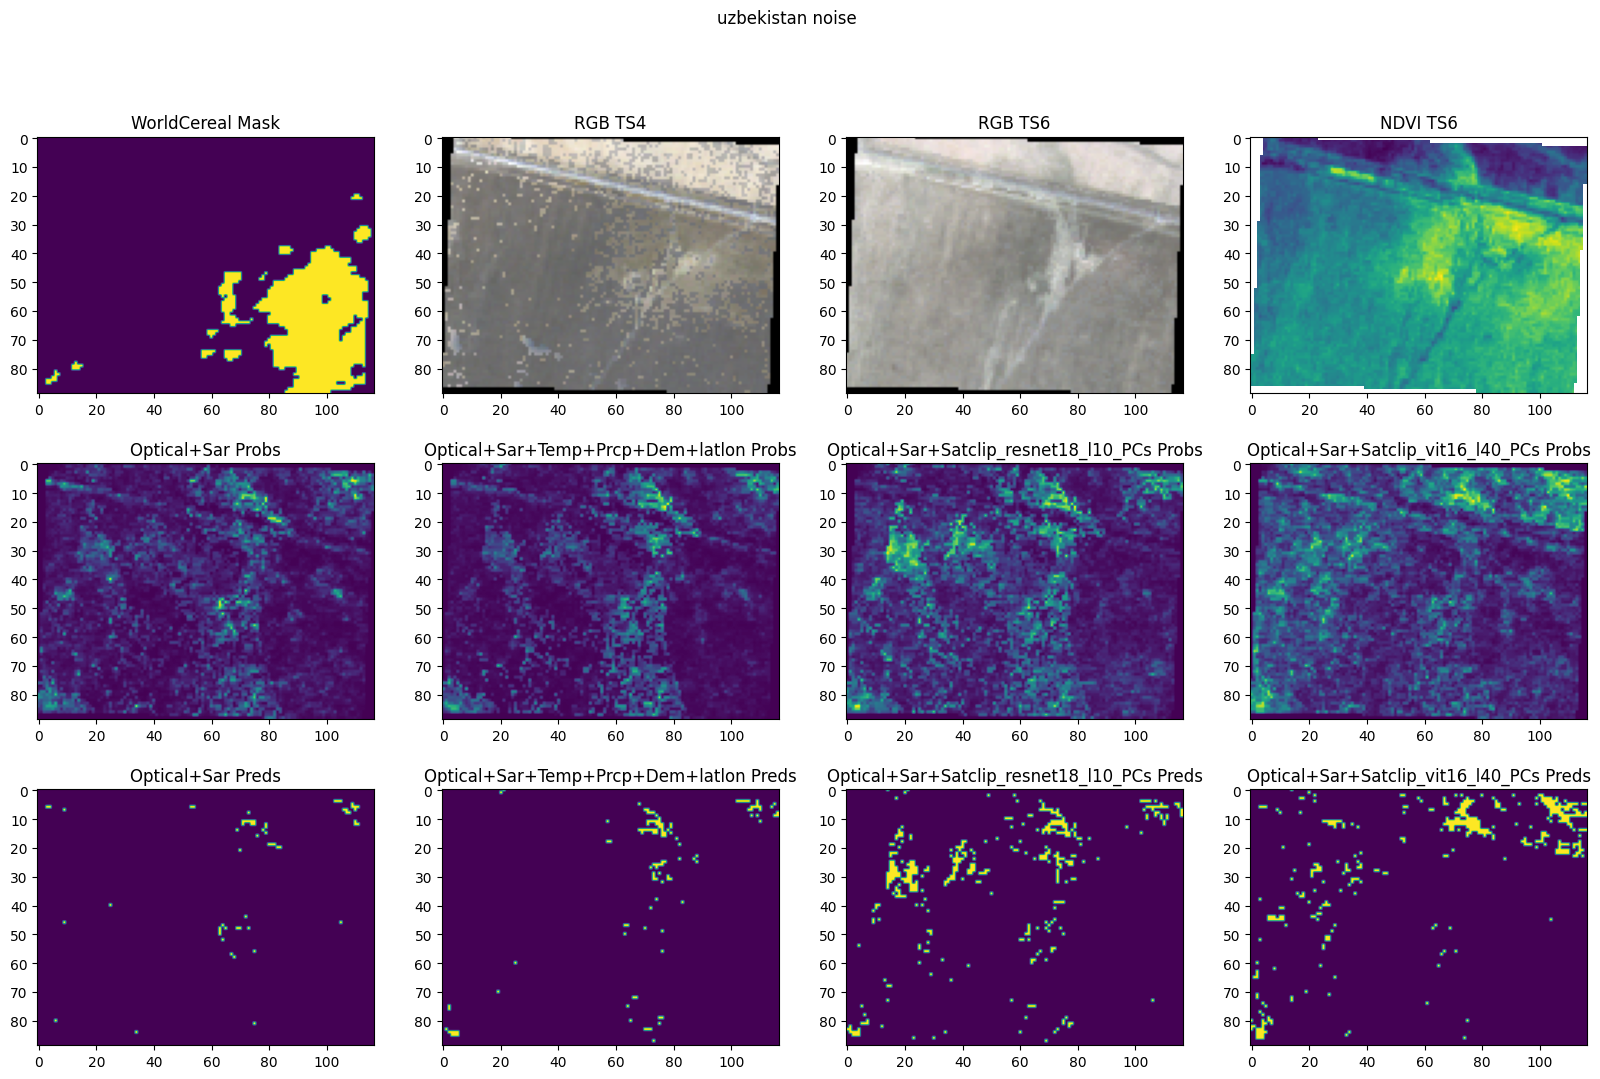

In [87]:
fig = plt.figure(figsize=(20,12))

fig.add_subplot(3, 4, 1)
plt.imshow(test_patch.worldcereal_cropland.values[0,:,:])
plt.title('WorldCereal Mask')

fig.add_subplot(3, 4, 2)
plt.imshow(test_patch_rgb_ts4)
plt.title('RGB TS4')

fig.add_subplot(3, 4, 3)
plt.imshow(test_patch_rgb_ts6)
plt.title('RGB TS6')

fig.add_subplot(3, 4, 4)
plt.imshow(test_patch_ndvi_ts6)
plt.title('NDVI TS6')

fig.add_subplot(3, 4, 5)
plt.imshow(test_patch_probs1.reshape(test_patch['y'].shape[0], test_patch['x'].shape[0]))
plt.title('Optical+Sar Probs')

fig.add_subplot(3, 4, 6)
plt.imshow(test_patch_probs2.reshape(test_patch['y'].shape[0], test_patch['x'].shape[0]))
plt.title('Optical+Sar+Temp+Prcp+Dem+latlon Probs')

# fig.add_subplot(3, 4, 7)
# plt.imshow(test_patch_probs3.reshape(test_patch['y'].shape[0], test_patch['x'].shape[0]))
# plt.title('Optical+Sar+Satclip_Emb Probs')

fig.add_subplot(3, 4, 7)
plt.imshow(test_patch_probs4.reshape(test_patch['y'].shape[0], test_patch['x'].shape[0]))
plt.title('Optical+Sar+Satclip_resnet18_l10_PCs Probs')

fig.add_subplot(3, 4, 8)
plt.imshow(test_patch_probs5.reshape(test_patch['y'].shape[0], test_patch['x'].shape[0]))
plt.title('Optical+Sar+Satclip_vit16_l40_PCs Probs')

fig.add_subplot(3, 4, 9)
plt.imshow(test_patch_preds1.reshape(test_patch['y'].shape[0], test_patch['x'].shape[0]))
plt.title('Optical+Sar Preds')

fig.add_subplot(3, 4, 10)
plt.imshow(test_patch_preds2.reshape(test_patch['y'].shape[0], test_patch['x'].shape[0]))
plt.title('Optical+Sar+Temp+Prcp+Dem+latlon Preds')

# fig.add_subplot(3, 4, 11)
# plt.imshow(test_patch_preds3.reshape(test_patch['y'].shape[0], test_patch['x'].shape[0]))
# plt.title('Optical+Sar+Satclip_Emb Preds')

fig.add_subplot(3, 4, 11)
plt.imshow(test_patch_preds4.reshape(test_patch['y'].shape[0], test_patch['x'].shape[0]))
plt.title('Optical+Sar+Satclip_resnet18_l10_PCs Preds')

fig.add_subplot(3, 4, 12)
plt.imshow(test_patch_preds5.reshape(test_patch['y'].shape[0], test_patch['x'].shape[0]))
plt.title('Optical+Sar+Satclip_vit16_l40_PCs Preds')

plt.suptitle(test_patch_name)

plt.savefig('/home/cbutsko/Desktop/cbutsko_experiments/spatial_inference_res/{}_satclip_models_comparison.png'.format(test_patch_name))

### Hierarchical classification

In [ ]:
# pretend that crop/not_crop is solved
# this is also necessary, as now kernel keeps crashing on full dataset 😢
data_df = data_df[data_df['cropland_wc']==1]
# label_columns = label_columns[1:]
label_columns.remove('cropland')
label_columns.remove('cropgroup')

In [ ]:
# create train/test datasets
stratification_col = 'croptype'
test_size = 0.3

trnval_df, tst_df = train_test_split(
    data_df,
    stratify=data_df[stratification_col],
    test_size=test_size,
    random_state=42)

X_trn_df = trnval_df[features_list]
y_trn_df = trnval_df[label_columns]

X_tst_df = tst_df[features_list]
y_tst_df = tst_df[label_columns]

In [ ]:
cb_clsfr = CatBoostClassifierWrapper(
    iterations=2000, 
    depth=8,
    eval_metric='F1',
    learning_rate=0.3,
    l2_leaf_reg=100,
    verbose=50,
    random_seed=42,
)

classifier = LocalClassifierPerNode(
    local_classifier=cb_clsfr,
    n_jobs=-1,
)

classifier.fit(X_trn_df, y_trn_df)
# pred, probs = classifier.predict_proba(X_tst_df)
pred = classifier.predict(X_tst_df)
pred = pred.astype('int32')

In [ ]:
# assess predictions at a level
level_ind = -1

level_true = y_tst_df[label_columns[level_ind]]
level_pred = pred[:,level_ind]

# map to human names
tmap = ec_map[['{}_label'.format(label_columns[level_ind]),'{}_name'.format(label_columns[level_ind])]].drop_duplicates()
tmap = dict(tmap.to_numpy())
level_true = level_true.map(tmap)
level_pred = [*map(tmap.get, level_pred)]

In [ ]:
print(classification_report(
    level_true, 
    level_pred, 
    target_names=np.sort(level_true.unique()))) 

In [ ]:
cm = confusion_matrix(level_true, level_pred)
plot_confusion_matrix(cm, np.unique(level_true))

**Compare to flat classifier**

In [ ]:
label_col = label_columns[-1]

# compare to performance on random split
trn_df, val_df = train_test_split(
    trnval_df,
    stratify=trnval_df['croptype'],
    test_size=0.3,
    random_state=42)

X_trn_df = trn_df[features_list]
y_trn_df = trn_df[label_col]
X_val_df = val_df[features_list]
y_val_df = val_df[label_col]

In [ ]:
# initialize and train the model
model = CatBoostClassifier(
    iterations=2000, 
    depth=8,
    eval_metric='TotalF1',
    learning_rate=0.3,
    l2_leaf_reg=100,
    verbose=50,
    random_seed=42,
    )

model.fit(X_trn_df, y_trn_df, eval_set=(X_val_df, y_val_df), early_stopping_rounds=200)
probs = model.predict_proba(X_tst_df)
pred = model.predict(X_tst_df).flatten()

In [ ]:
true = y_tst_df.reset_index(drop=True)[label_col]
pred = pd.Series(model.predict(X_tst_df).flatten())

# # map to human names
# tmap = ec_map[['{}_label'.format(label_columns[-1]),'{}_name'.format(label_columns[-1])]].drop_duplicates()
# tmap = dict(tmap.to_numpy())
# true = true.map(tmap)
# pred = pred.map(tmap)
# pred.fillna('unknown', inplace=True)
# pred = pd.Series([*map(tmap.get, pred)])

In [ ]:
print(classification_report(
    true, 
    pred, 
    # target_names=np.sort(true.unique())
    )) 

In [ ]:
cm = confusion_matrix(true, pred)
plot_confusion_matrix(cm, np.unique(list(np.unique(true)) + list(np.unique(pred))))

**Using probabilities to train a simple meta learner**

In [ ]:
_, probs_trn = classifier.predict_proba(X_trn_df)
_, probs_tst = classifier.predict_proba(X_tst_df)

probs_features_trn = np.concatenate((
    probs_trn['l0'],
    probs_trn['l1']['1101']), axis=1)
probs_features_tst = np.concatenate((
    probs_tst['l0'], 
    probs_tst['l1']['1101']), axis=1)

In [ ]:
logreg_meta_learner_probs_model = LogisticRegression(random_state=42).fit(
    probs_features_trn, 
    y_trn_df[label_columns[-1]].values)

logreg_meta_learner_pred = logreg_meta_learner_probs_model.predict(probs_features_tst) 
tmap = ec_map[['{}_label'.format(label_columns[-1]),'{}_name'.format(label_columns[-1])]].drop_duplicates()
tmap = dict(tmap.to_numpy())
logreg_meta_learner_pred = [*map(tmap.get, logreg_meta_learner_pred)]

In [ ]:
print(classification_report(
    level_true, 
    logreg_meta_learner_pred, 
    target_names=np.sort(level_true.unique())))

In [ ]:
preds_df = pd.DataFrame([level_true.values, level_pred, logreg_meta_learner_pred]).transpose()
preds_df.columns = ['true','hiclass_pred','logreg_meta_pred']

In [ ]:
crops_lst = ['arable_crops', 'not_cereal', 'cereals', 'unspecified_cereal', 'wheat', 'barley', 'rye', 'oats', 'maize', 'millet_sorghum', 'rice']
ii = 442
['{}: {}'.format(ii,jj) for ii, jj in zip(crops_lst, np.round(probs_features_tst[ii,:], 2))]

In [ ]:
preds_df[
    (preds_df['hiclass_pred']==preds_df['true']) &
    (preds_df['logreg_meta_pred']!=preds_df['true'])
    ][['true','logreg_meta_pred']].value_counts().sort_index()